In [1]:
import numpy as np
import pandas as pd

In [2]:
# 设置随机种子
np.random.seed(42)

# 生成400个样本
n_samples = 400

# 生成特征
# 1. 房屋面积 (平方米)
area = np.random.uniform(50, 200, n_samples)

# 2. 卧室数量
bedrooms = np.random.choice([1, 2, 3, 4, 5], n_samples, p=[0.1, 0.3, 0.4, 0.15, 0.05])

# 3. 房龄 (年)
age = np.random.exponential(10, n_samples)
age = np.clip(age, 0, 50)  # 限制在0-50年

# 4. 地理位置评分 (1-10分)
location = np.random.normal(6, 2, n_samples)
location = np.clip(location, 1, 10)

# 生成目标变量：房价 (万元)
# 真实关系：price = 0.8*area + 15*bedrooms - 0.5*age + 8*location + 30 + noise
noise = np.random.normal(0, 20, n_samples)
price = 0.8 * area + 15 * bedrooms - 0.5 * age + 8 * location + 30 + noise

# 创建DataFrame
data = pd.DataFrame({
    'area': area,
    'bedrooms': bedrooms,
    'age': age,
    'location': location,
    'price': price
})


In [3]:
rng_divide=np.random.default_rng(17)

data_train=data.sample(frac=0.67,random_state=rng_divide)
data_test=data.sample(frac=0.33)
data_train.head()

,area,bedrooms,age,location,price
186,172.583330,1,11.660427,6.300838,225.989540
365,107.915396,3,17.035674,7.676982,187.310738
26,79.951067,3,4.251771,5.835698,171.990341
39,116.022874,1,10.003908,9.601881,190.966033
281,100.699274,2,0.936636,9.499153,211.037258


In [4]:
#normalize
Mean=data_train.mean(axis=0)
Std=data_train.std(axis=0)
dataTrain_normalized=(data_train-Mean)/Std  #can be optimized
dataTrain_normalized.head()

,area,bedrooms,age,location,price
186,1.123428,-1.748388,0.232495,0.126271,0.238032
365,-0.307932,0.280045,0.803037,0.843644,-0.588638
26,-0.926894,0.280045,-0.553880,-0.116203,-0.916077
39,-0.128481,-1.748388,0.056667,1.847079,-0.510515
281,-0.467653,-0.734172,-0.905757,1.793528,-0.081539


In [5]:
def sigmoid(x):
    return 1/(1+np.exp(-x))
    

In [6]:
def get_loss(y,y_hat):
    return 1/2*pow((y_hat-y),2)

In [7]:
def upgrade_parameter(y,y_hat,x,level_1_to_2,\
              primary_parameter,alph=1):
    
    
    g=y_hat-y
    delta_power2=-alph*g*level_1_to_2
    delta_threshold2=-alph*g

    e=level_1_to_2*(1-level_1_to_2)*primary_parameter['power2']*g    #对后两项，我这里只是一维的输出，power2是1*7的
    delta_power1=-alph*x.reshape(-1,1)@e.reshape(1,-1)    #e,xi都是向量，最后会做成一个4*7的
    delta_threshold1=-alph*(-e)

    primary_parameter['power2']+=delta_power2
    primary_parameter['threshold2']+=delta_threshold2
    primary_parameter['power1']+=delta_power1
    primary_parameter['threshold1']+=delta_threshold1

    return primary_parameter


In [8]:
def rf_standard_BP(data,primary_parameter,loop):
    x=data.iloc[:-1].values
    y=data.iloc[-1]
    
    #input to level1
    level_1=x@primary_parameter['power1'] #向量，直接计算了内积
    #deal and output
    level_1_to_2=sigmoid(level_1-primary_parameter['threshold1'])
    

    #input to level2
    level_2=level_1_to_2@primary_parameter['power2']
    #deal and output
    
    
    y_hat=level_2+primary_parameter['threshold2'][0]    #why ?  #because array([1]) is not array(1)

    global rf_loss_sum  ###GLOBAL!!
    if loop%1500==0:
        rf_loss_sum+=get_loss(y,y_hat)
        print(f'mean loss:{(rf_loss_sum/((loop/1500)+1)):.6f}')

    primary_parameter=\
    upgrade_parameter(y,y_hat,x,level_1_to_2,\
                      primary_parameter,alph=0.1)
    
    return primary_parameter   

In [9]:
def rf_test_standardBP(data_test,primary_parameter):
    x=data_test.values
    
    
    #input to level1
    level_1=x@primary_parameter['power1'] #向量，直接计算了内积
    #deal and output
    level_1_to_2=sigmoid(level_1-primary_parameter['threshold1'])
   
    #input to level2
    level_2=level_1_to_2@primary_parameter['power2']
    #deal and output
    
   
    y_hat=level_2+primary_parameter['threshold2'][0]

    return y_hat

In [56]:
rf_loss_sum=0
rng=np.random.default_rng(17)
learner=25
rf_train_len=len(dataTrain_normalized)
rf_dict_parameter={}

all_columns=list(data_train.columns)
columns=all_columns[:-1]
len_columns=len(columns)
#seleceSize=round(np.log(len_columns)/np.log(2))
seleceSize=3                  #Although the book recommend lo2gk,use 3 is better here.May be the feture is too small.
#print(len_columns)

for t in range(learner):  
    print(f"learner {t}")
    rf_loss_sum=0
    columns_selected=rng.choice(columns,seleceSize,replace=False).tolist()
    dataTrain_selectColumns=dataTrain_normalized.loc[:,columns_selected]
    dataTrain_y=dataTrain_normalized.iloc[:,-1]
    dataTrain_selected=pd.concat([dataTrain_selectColumns,dataTrain_y],axis=1)
    
    rf_train=dataTrain_selected.sample(frac=1,replace=True)
    
    rf_primary_parameter={'power1':rng.random((seleceSize,7))*0.1,\
                   'threshold1':rng.random(7)*0.1,\
                   'power2':rng.random(7)*0.1,\
                   'threshold2':rng.random(1)*0.1}
    for j in range(10):
        for i in range(rf_train_len):
            loop=rf_train_len*j+i
            rf_primary_parameter=\
            rf_standard_BP(rf_train.iloc[i],rf_primary_parameter,loop)
    try:
        rf_dict_parameter[" ".join(columns_selected)].append(rf_primary_parameter)
    except:
        rf_dict_parameter[" ".join(columns_selected)]=[rf_primary_parameter]
    
    

learner 0
mean loss:0.225403
mean loss:0.149353
learner 1
mean loss:1.187916
mean loss:0.649561
learner 2
mean loss:0.242282
mean loss:0.182308
learner 3
mean loss:0.065851
mean loss:0.084352
learner 4
mean loss:0.026633
mean loss:0.035158
learner 5
mean loss:0.000000
mean loss:0.065826
learner 6
mean loss:0.001099
mean loss:0.086318
learner 7
mean loss:0.583723
mean loss:0.390328
learner 8
mean loss:0.677149
mean loss:0.342150
learner 9
mean loss:1.106326
mean loss:0.566890
learner 10
mean loss:0.023430
mean loss:0.012005
learner 11
mean loss:0.271907
mean loss:0.140194
learner 12
mean loss:0.096281
mean loss:0.321512
learner 13
mean loss:0.324390
mean loss:0.500404
learner 14
mean loss:0.063926
mean loss:0.064255
learner 15
mean loss:0.080288
mean loss:0.199660
learner 16
mean loss:0.516757
mean loss:0.261605
learner 17
mean loss:0.109057
mean loss:0.054560
learner 18
mean loss:0.043895
mean loss:0.334699
learner 19
mean loss:1.604576
mean loss:0.880318
learner 20
mean loss:0.127874


In [57]:
dataTest_normalized=(data_test-Mean)/Std
dataTest_normalized.head()

,area,bedrooms,age,location,price
57,-0.939148,0.280045,-0.327150,-1.238247,-0.942030
208,-1.573026,0.280045,-0.700290,1.209570,-0.499643
96,0.145694,0.280045,-0.636929,1.770556,0.339515
258,0.302829,0.280045,-0.311333,-1.054880,0.023416
229,0.505612,-0.734172,0.868878,2.054616,0.341808


In [58]:
print(rf_dict_parameter.keys(),'\n')
print(rf_dict_parameter['location area bedrooms'])

dict_keys(['age area bedrooms', 'bedrooms area location', 'location area bedrooms', 'age bedrooms area', 'area location age', 'bedrooms location area', 'location area age', 'location bedrooms area', 'location bedrooms age', 'area bedrooms location', 'age location area', 'bedrooms age location', 'area age bedrooms', 'bedrooms area age', 'bedrooms location age']) 

[{'power1': array([[ 0.51659048,  0.20673793,  0.13372036,  0.09810354,  0.53434565,
         0.11291659,  0.15002856],
       [ 0.98962373,  0.55610826,  0.51259303,  0.71171526,  1.02090508,
         0.57743972,  0.4473358 ],
       [-0.20182229,  0.30358314,  0.47874964,  0.6629047 , -0.24092021,
         0.55730056,  0.32543268]]), 'threshold1': array([0.23552289, 0.49690342, 0.50227046, 0.48953239, 0.2662706 ,
       0.5240262 , 0.4815775 ]), 'power2': array([0.87829435, 0.48558297, 0.50313554, 0.81413957, 0.92512266,
       0.59596764, 0.37336911]), 'threshold2': array([-2.07732415])}, {'power1': array([[ 0.16661501,  0.

In [59]:
rf_test_preduction=pd.Series(np.zeros(len(dataTest_normalized)),index=dataTest_normalized.index)
for key in rf_dict_parameter.keys():
    lens=len(rf_dict_parameter[key])
    rf_test_ononekey=pd.Series(np.zeros(len(dataTest_normalized)),index=dataTest_normalized.index)
    for i in range(lens):
        li=rf_dict_parameter[key]
               
        rf_test_ononekey+=dataTest_normalized.loc[:,key.split(' ')]\
                .apply(rf_test_standardBP,axis=1,args=(li[i],))
        #write with your patience
        
    rf_test_preduction+=rf_test_ononekey/lens
rf_test_preduction=rf_test_preduction/len(rf_dict_parameter)
rf_test_preduction.head()

57    -0.865727
208   -0.641281
96     0.560938
258   -0.032750
229    0.540700
dtype: float64

In [60]:
dataTest_normalized.head()['price']

57    -0.942030
208   -0.499643
96     0.339515
258    0.023416
229    0.341808
Name: price, dtype: float64

In [61]:
rf_final_testPreduction=rf_test_preduction*Std['price']+Mean['price']
rf_final_testPreduction.name='RandomForest_preduction'
result=pd.concat([data_test['price'],rf_final_testPreduction],axis=1)
print(result.head())

          price  RandomForest_preduction
57   170.776031               174.346114
208  191.474722               184.847669
96   230.737778               241.097885
258  215.947937               213.320014
229  230.845068               240.150957


In [62]:
import matplotlib.pyplot as plt 
%matplotlib inline

<Axes: title={'center': 'Preduction by RF VS the True Price'}, xlabel='price', ylabel='RandomForest_preduction'>

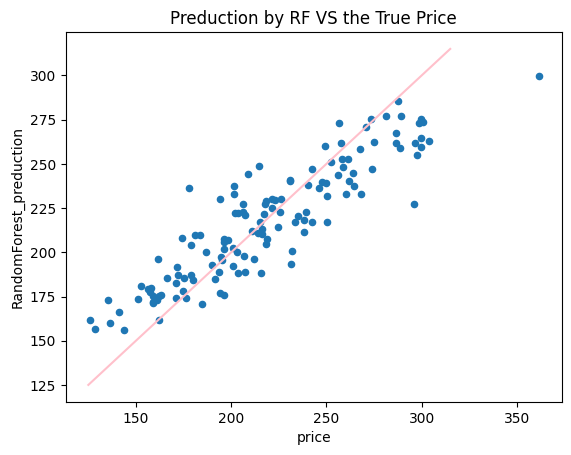

In [67]:
result.plot(kind='scatter',x='price',y='RandomForest_preduction',title='Preduction by RF VS the True Price')
xy=pd.Series(np.arange(125,325,10),index=np.arange(125,325,10))
xy.plot(kind='line',color='pink')

In [64]:
MeanSqu_error=pow(result['price']-result['RandomForest_preduction'],2).mean()
print(f'Mean Squared Error:{MeanSqu_error}')
print(f'Root Mean Squared Error:{pow(MeanSqu_error,0.5)}')

Mean Squared Error:469.508708876387
Root Mean Squared Error:21.6681496412681
